In [ ]:
import hcipy
import matplotlib.pyplot as plt
import numpy as np
import configparser
import pandas as pd
import tqdm

class WavefrontSC(hcipy.Wavefront):
    def subregion(
        self,
        origin: tuple[int, int],
        pix_w: int,
    ) -> hcipy.Wavefront:
        """Get a sub-region of the wavefront as a separate wavefront

        Args:
           origin (tuple): Integer positions of top-left corner in pixels.
           pix_w (int): Width of square region to cut from origin.

        Returns:
            hcipy.Wavefront: Returned sub-region as a wavefront
        """
        #print(np.array(self.electric_field.data).shape)
        efield = np.array(self.electric_field.data).reshape(self.grid.shape)
        #stokes = np.array(self.stokes_vector.data).reshape((4,)+self.grid.shape)
        origin = np.array(origin).astype(int)

        efield_sr = efield[origin[0]: origin[0] + pix_w,
                           origin[1]: origin[1] + pix_w]
        #stokes_sr = stokes[:, origin[0]+pix_w, origin[1]+pix_w]
        new_grid = hcipy.make_pupil_grid(
            efield_sr.shape, diameter=pix_w*self.grid.delta[0])

        efield_sr = efield_sr.flatten()
        #stokes_sr = stokes_sr.reshape((4, int(pix_w**2)))

        new_efield = hcipy.Field(efield_sr, grid=new_grid)
        #new_stokes = hcipy.Field(stokes_sr, grid=new_grid)

        return hcipy.Wavefront(
            electric_field=new_efield,
            wavelength=self.wavelength,
            #input_stokes_vector=new_stokes
        )

ELT_DIA = 39.14634

pupil_grid = hcipy.make_pupil_grid(dims=1024, diameter=ELT_DIA)
#pupil_grid = hcipy.make_pupil_grid(1024,100e-3)
#eltgrid = hcipy.make_circular_aperture(13.5e-3)(pupil_grid)

ELT_AP  = hcipy.make_elt_aperture()
eltgrid = ELT_AP(pupil_grid)

fpgrid  = hcipy.make_focal_grid(20, 30, f_number=850, reference_wavelength=800e-9)


ELTFocusProp = hcipy.FraunhoferPropagator(pupil_grid, fpgrid, focal_length=850 * ELT_DIA)

wf = hcipy.Wavefront(eltgrid, wavelength=800e-9)
wf2 = ELTFocusProp.forward(wf)
#wf2 = hcipy.Wavefront(hcipy.make_rectangular_aperture(0.01)(fpgrid), wavelength=800e-9)


class ImageSlicer(hcipy.OpticalElement):
    def __init__(self, config_file: str):
        """Init function."""
        super().__init__()
        self._read_in_cfg(config_file)

    def _read_in_cfg(self, config_file):
        parser = configparser.ConfigParser()
        parser.read(config_file)

        cfg = parser['CONFIG']

        self.no_slices = int(cfg['spaxels'])
        self.slice_dims = tuple(float(x.strip()) for x in cfg['slice_dims'].split(','))
        self.pupil_dims = tuple(float(x.strip()) for x in cfg['pupil_dims'].split(','))
        self.transmission = float(cfg['transmission'])
        self.slicer_decenter = tuple(float(x.strip()) for x in cfg['slicer_decenter'].split(','))
        self.pupil_decenter = tuple(float(x.strip()) for x in cfg['pupil_decenter'].split(','))
        self.rotation = np.radians(float(cfg['stack_rotation']))
        self.mirror_file = cfg.get('mirror_file', '')
        self.mirror_file = pd.read_csv(self.mirror_file)

        self.slicer_dims = (self.slice_dims[0], self.slice_dims[1] * self.no_slices)

    def _get_slice_centres(self):
        slice_centres = np.zeros((self.no_slices, 2))
        slice_centres[:,1] = np.arange(self.no_slices) * self.slice_dims[1]
        slice_centres[:,1] -= (self.no_slices // 2) * self.slice_dims[1]
        if self.no_slices%2 == 0:
            slice_centres[:,1] += 0.5 * self.slice_dims[1]
        return slice_centres + np.array(self.slicer_decenter)

    def _get_pupil_centres(self):
        pupil_centres = np.zeros((self.no_slices, 2), dtype=np.float32)
        pupil_centres[:,1] = np.arange(self.no_slices) * self.pupil_dims[1]
        pupil_centres[:,1] -= (self.no_slices // 2) * self.pupil_dims[1]
        if self.no_slices %2 == 0:
            pupil_centres[:,1] += 0.5 * self.pupil_dims[1]
        return pupil_centres + np.array(self.pupil_decenter)

    def _split_field(self, focal_plane: hcipy.Wavefront) -> list[hcipy.Wavefront]:
        """Split the input field using apodisation with rectangular apertures.
        """
        slice_centres = self._get_slice_centres()
        slice_centres_pix = np.nan_to_num(
            np.round(slice_centres / focal_plane.grid.delta[0]).astype(int))

        R = np.array([
            [np.cos(self.rotation), -np.sin(self.rotation)],
            [np.sin(self.rotation), np.cos(self.rotation)]])

        slice_centres_pix = np.einsum('ij,pj->pi', R, slice_centres_pix)
        slice_centres_pix += np.array(focal_plane.grid.shape) // 2
        slice_centres_pix += np.array(self.slicer_decenter)
        subregion_size = int(max(self.slice_dims) / focal_plane.grid.delta[0])

        sub_images = []
        for p in tqdm.tqdm(
            range(slice_centres.shape[0]),
            colour='red',
            desc='Slicing Field',
            leave=False):

            slice_mask = hcipy.make_rectangular_aperture(
                size = self.slice_dims,
                center = slice_centres[p])
            slice_mask = hcipy.make_rotated_aperture(
                slice_mask, angle=self.rotation)
            apodizer = hcipy.Apodizer(slice_mask)
            wf = apodizer.forward(focal_plane)

            wf_temp = WavefrontSC(wf.electric_field, wf.wavelength)
            wf_subregion = wf_temp.subregion(
                origin=(slice_centres_pix[p,1] - subregion_size//2, 
                        slice_centres_pix[p,0] - subregion_size//2),
                pix_w= subregion_size
            )
            sub_images.append(wf_subregion)
        return sub_images

    def _propto_pupil_mirror(self, sub_images):

        fmin = np.min(np.abs(self.mirror_file.loc[:,'EFL'] * 1e-3))
        input_grid_D = sub_images[0].grid.delta[0] * sub_images[0].grid.shape[0]
        resolution = fmin/input_grid_D * 800e-9

        output_grid = hcipy.make_focal_grid(
            10,
            num_airy=abs(6e-3)/(2*resolution),
            spatial_resolution=resolution
        )
    
        ims_out = []

        for ix, im in tqdm.tqdm(
            enumerate(sub_images),
            desc='Pupil Mirror',
            colour='blue',
            leave=False,
            total=self.no_slices):
            prop = hcipy.FraunhoferPropagator(
                im.grid,
                output_grid,
                focal_length=abs(self.mirror_file.loc[ix,'EFL'] * 1e-3)
            )
            imout = prop.forward(im)
            ims_out.append(imout)

        return ims_out

    def _apply_pupil_mirror(self, pupil_images):
        pupil_images_apod = []
        for n, im in tqdm.tqdm(enumerate(pupil_images), total=self.no_slices, leave=False, colour='green', desc='Pupil apod'):
            pupil_mirror = hcipy.make_rectangular_aperture(
                self.pupil_dims,
                self.pupil_decenter
            )
            pupil_mirror = hcipy.make_rotated_aperture(
                pupil_mirror,
                angle=self.rotation
            )
            apod = hcipy.Apodizer(pupil_mirror)
            apod_im = apod.forward(im)
            pupil_images_apod.append(apod_im)
        return pupil_images_apod

    def _create_slicer_mirror(self):
        return

    def forward(self, wavefront):
        return 
    def backward(self, wavefront):
        return


: 

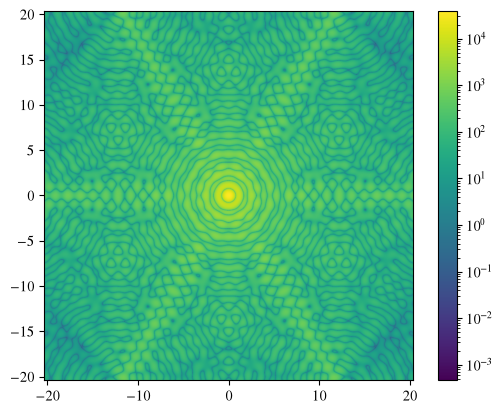

Pupil Mirror:  78%|███████▊  | 35/45 [00:22<00:06,  1.54it/s]]

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
hcipy.imshow_field(wf2.amplitude, norm='log', grid_units=1e-3)
plt.colorbar()
plt.show()

#test_im = hcipy.make_pupil_grid(128, 0.25)


im = ImageSlicer('./slicer.cfg')
ims = im._split_field(wf2)
pups = im._propto_pupil_mirror(ims)

#print(ims[0].grid.shape, ims[0].grid.delta)

pups_apod = im._apply_pupil_mirror(pups)

print(ims[0].amplitude)

plt.figure()
hcipy.imshow_field(ims[0].amplitude)
plt.colorbar()
plt.figure()
hcipy.imshow_field(pups[0].power)
plt.show()




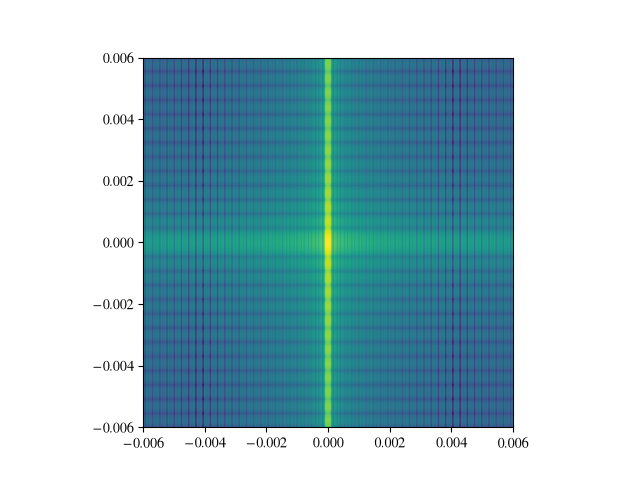

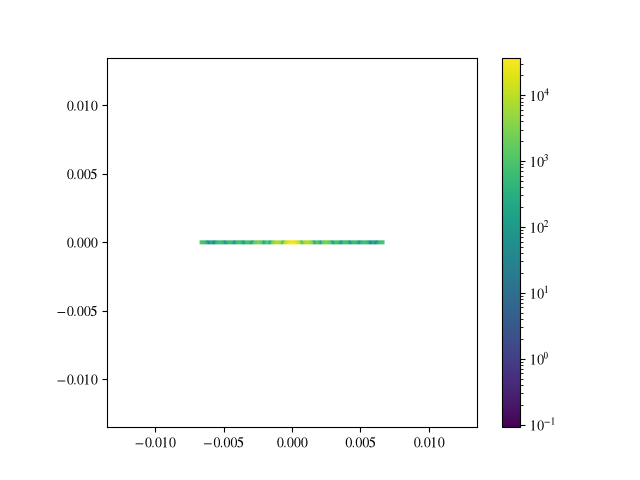

In [ ]:
plt.figure()
hcipy.imshow_field(ims[23].amplitude, norm='log')
plt.colorbar()
plt.figure()
hcipy.imshow_field(pups[23].power, norm='log')
plt.show()

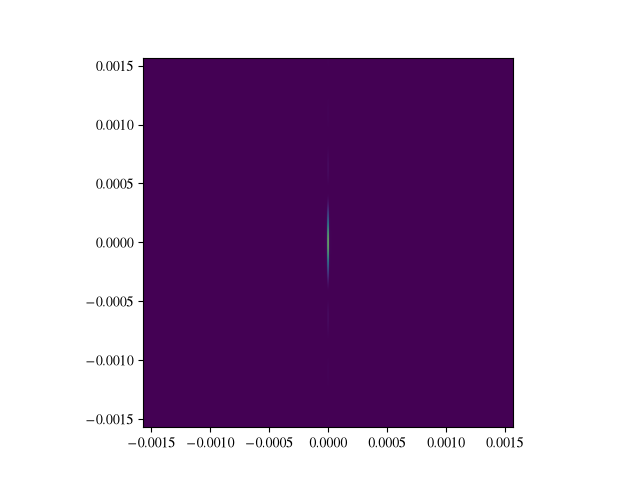

In [37]:
%matplotlib widget
testpupil = hcipy.make_pupil_grid(2040,26e-3)
m = hcipy.make_rectangular_aperture((13.5e-3, 0.3e-3))(testpupil)
wf = hcipy.Wavefront(m, wavelength=800e-9)


FPout = hcipy.make_focal_grid(10, num_airy=300, spatial_resolution=5.23e-6)
Franhof = hcipy.FraunhoferPropagator(testpupil, FPout, focal_length=170e-3)
wfm = Franhof.forward(wf)

plt.figure()
hcipy.imshow_field(wfm.power)

In [42]:
wf.grid.delta  * wf.grid.shape[0]


array([0.026, 0.026])